In [1]:
import torch
torch.cuda.is_available()

False

In [2]:
# Graph aesthetics settings
import matplotlib.pyplot as plt
from cycler import cycler
import seaborn as sns
large = 20; medium = 16; small = 12
colors = ['#66bb6a', '#558ed5', '#dd6a63', '#dcd0ff', '#ffa726', '#8c5eff', '#f44336', '#00bcd4', '#ffc107', '#9c27b0']
text_color = "#404040"

params = {'axes.titlesize': medium,
          'legend.fontsize': small,
          'figure.figsize': (16, 16),
          'axes.labelsize': small,
          'axes.linewidth': 2,
          'xtick.labelsize': small,
          'xtick.color': text_color,
          'ytick.color': text_color,
          'ytick.labelsize': small,
          'axes.edgecolor': text_color,
          'figure.titlesize': small,
          'axes.prop_cycle': cycler(color=colors),
          'axes.titlecolor': text_color,
          'axes.labelcolor': text_color,
         }

plt.rcParams.update(params)

In [3]:
import torch
import numpy as np
import torch.nn as nn
from neurodiffeq import diff      
from neurodiffeq.ode import solve 
from neurodiffeq.conditions import IVP 
from neurodiffeq.networks import FCNN
from neurodiffeq.solvers import Solver1D
from neurodiffeq.generators import Generator1D

In [4]:
def plot_loss(solver):
    history = solver.metrics_history
    plt.figure(figsize=(8,5))
    plt.plot(np.log10(history['train_loss']), label = 'Train')
    
    # Add axis labels, title and legend for clarity
    plt.title('Loss plot')
    plt.xlabel('epochs')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_results(solver):
    history = solver.metrics_history
    t_vals = np.linspace(solver.t_min, solver.t_max, 256)
    u_pred = solver.get_solution()(t_vals, to_numpy=True)
    plt.figure(figsize=(8,5))
    #plt.plot(t_vals, [np.sin(i) for i in t_vals], c = colors[1])
    plt.plot(t_vals, u_pred, '--', c = colors[0])
    
    # Add axis labels and title for clarity
    plt.title(f'Neural Network approximation at {len(history["train_loss"])} epochs.')
    plt.xlabel('u')
    plt.ylabel('t')
    plt.grid(True)
    plt.show()

In [5]:

class AdditionModel(nn.Module):
    def __init__(self, n_input_units=1, hidden_units=[16, 16], actv=nn.Tanh, n_output_units=1):
        super(AdditionModel, self).__init__()
        self.input_layer = nn.Linear(n_input_units, hidden_units[0])
        self.actv = actv()
        self.hidden_layers = nn.ModuleList()
        for i in range(1, len(hidden_units)):
            self.hidden_layers.append(nn.Linear(hidden_units[i - 1], hidden_units[i]))
            self.hidden_layers.append(actv())
        self.output_layer = nn.Linear(hidden_units[-1], n_output_units)

    def forward(self, x):
        sin, cos = torch.sin(1e-4 * x), torch.cos(1e-4 * x)
        time_embeddings = torch.zeros([256,1])
        time_embeddings[0::2] = sin[0::2]
        time_embeddings[1::2] = cos[1::2]
        input_vector = self.input_layer(x)
        x = self.actv(input_vector) + time_embeddings
        for layer in self.hidden_layers:
            x = layer(x)
        output_vector = self.output_layer(x)
        return output_vector

In [6]:
def harmonic_oscillator(u, t):
    return [diff(u, t, order=2) + 16*torch.pi**2*torch.sin(u)]
init_val_ho = [IVP(t_0=0.0, u_0=0.0, u_0_prime=1.0)]
nets = [AdditionModel(n_input_units=1, hidden_units=[32, 32], actv=nn.Tanh, n_output_units=1)]
t_min = 0
t_max = 1
train_g = Generator1D(256, t_min, t_max , method='equally-spaced-noisy')
valid_g = Generator1D(64, t_min, t_max , method='uniform')

In [7]:
solver = Solver1D(ode_system=harmonic_oscillator, 
                    conditions=init_val_ho, 
                    t_min=t_min, 
                    t_max=t_max,
                    n_batches_valid=0,
                    train_generator=train_g,
                    valid_generator=valid_g,
                    nets = nets)

Training Progress:   0%|                                                                      | 0/5000 [00:00<…

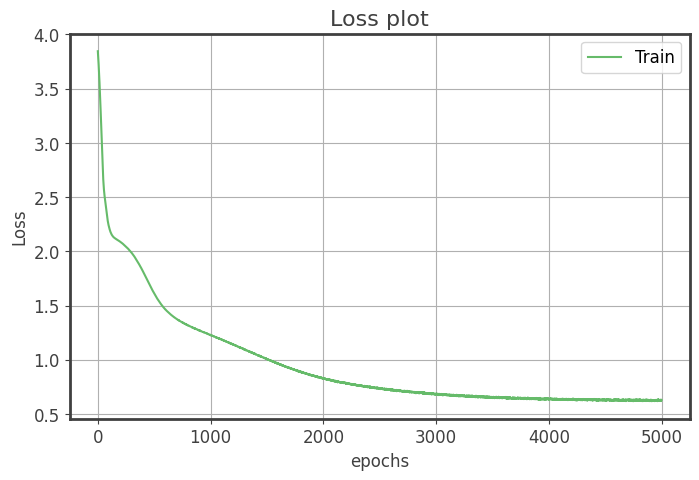

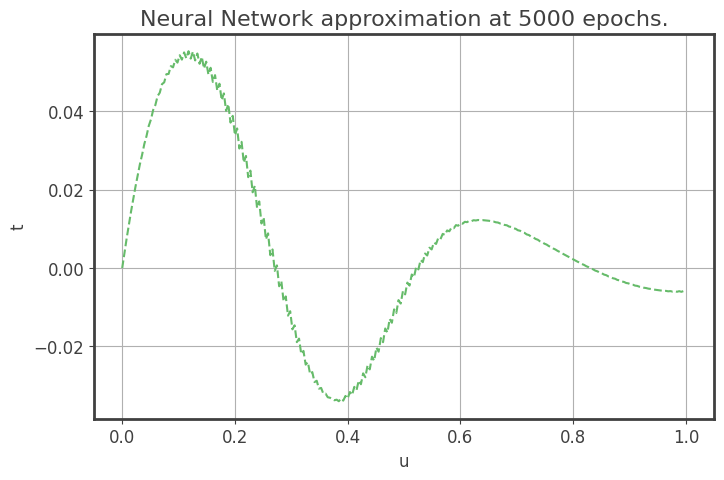

In [8]:
solver.fit(max_epochs=5000)
plot_loss(solver)
plot_results(solver)